##### 1-Imports + chemins 2-Télécharger datase 3-Charger raw + garder colonnes utiles
##### 4-Nettoyage / prétraitement 3-Train/test split
##### 6-Modèle baseline amélioré (SVM + balanced + bigrams) 7-Sauvegarde du modèle 8-Test rapide (prédiction)


##### 1-Imports + chemins

In [1]:
from pathlib import Path
import pandas as pd
import re

DATA_RAW = Path("../data/raw")
DATA_PROC = Path("../data/processed")
MODELS = Path("../models")

DATA_PROC.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)


##### 2-Télécharger dataset

In [2]:
from datasets import load_dataset

ds_sp = load_dataset("UniversalCEFR/cefr_sp_en")
ds_asag = load_dataset("UniversalCEFR/cefr_asag_en")

df_sp = pd.DataFrame(ds_sp["train"])
df_asag = pd.DataFrame(ds_asag["train"])

df_sp.to_csv(DATA_RAW/"cefr_sp_en_raw.csv", index=False, encoding="utf-8")
df_asag.to_csv(DATA_RAW/"cefr_asag_en_raw.csv", index=False, encoding="utf-8")

print(len(df_sp), len(df_asag))


c:\Users\hamouchizineb\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


10004 299


##### 3-Charger raw + garder colonnes utiles

In [3]:
df_sp = pd.read_csv(DATA_RAW/"cefr_sp_en_raw.csv")[["text", "cefr_level"]]
df_asag = pd.read_csv(DATA_RAW/"cefr_asag_en_raw.csv")[["text", "cefr_level"]]

df = pd.concat([df_sp, df_asag], ignore_index=True)
df.head()


,text,cefr_level
0,Is that your bike ?,A1
1,She had a beautiful necklace around her neck .,A1
2,I forgot to bring my umbrella .,A1
3,The baby kept crying .,A1
4,Do you know what you 're doing this weekend ?,A1


##### 4-Nettoyage / prétraitement

In [4]:
LEVELS = {"A1","A2","B1","B2","C1","C2"}

def clean_text(t):
    if not isinstance(t, str):
        return ""
    t = t.strip()
    t = re.sub(r"\s+", " ", t)
    return t

df["text"] = df["text"].apply(clean_text)
df = df[df["text"].str.len() > 0]
df = df[df["cefr_level"].isin(LEVELS)]
df = df[df["text"].str.len() <= 400]   # limite utile
df = df.drop_duplicates()

df["cefr_level"].value_counts()


cefr_level
B2    3379
B1    3366
C1    1766
A2    1315
C2     232
A1     141
Name: count, dtype: int64

#### Sauvegarder le dataset propre :

In [5]:
df.to_csv(DATA_PROC/"cefr_en_processed.csv", index=False, encoding="utf-8")
print("Saved:", DATA_PROC/"cefr_en_processed.csv", "rows=", len(df))


Saved: ..\data\processed\cefr_en_processed.csv rows= 10199


#### Train/test split

In [6]:
from sklearn.model_selection import train_test_split

X = df["text"]
y = df["cefr_level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


##### 6-Modèle baseline amélioré (SVM + balanced + bigrams)

Matplotlib is building the font cache; this may take a moment.


{'clf__C': 0.5, 'tfidf__max_features': 12000, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1)}


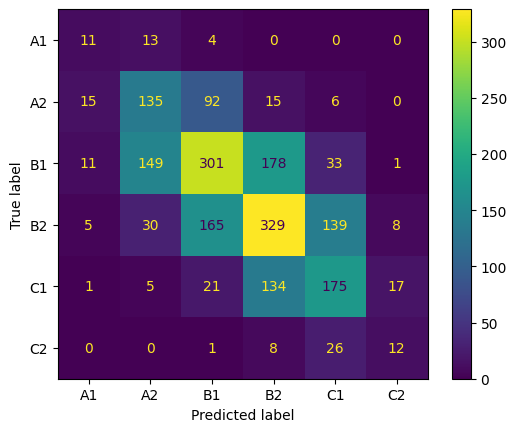

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
pipe = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LinearSVC(class_weight="balanced"))
])

params = {
    "tfidf__max_features": [8000, 12000, 20000],
    "tfidf__ngram_range": [(1,1),(1,2)],
    "tfidf__min_df": [1,2,5],
    "clf__C": [0.5, 1.0, 2.0]
}

gs = GridSearchCV(pipe, params, cv=3, n_jobs=-1, scoring="f1_macro")
gs.fit(X_train, y_train)

print(gs.best_params_)
best_model = gs.best_estimator_
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.show()


#### 7-Sauvegarde du modèle

In [11]:
import joblib

joblib.dump(model, MODELS/"cefr_model.pkl")
print("Saved:", MODELS/"cefr_model.pkl")


Saved: ..\models\cefr_model.pkl


#### 8-Test rapide (prédiction)

In [12]:
samples = [
    "My name is Sarah. I like cats.",
    "Although the proposal seems plausible, it lacks empirical support.",
    "I have been studying English for two years and I want to improve."
]

print(model.predict(samples))


['A1' 'C1' 'B1']
